<a href="https://colab.research.google.com/github/LizethArista/Manejo_de_datos/blob/main/Expresiones_regulares_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expresiones Regulares en Python

## Que son las Expresiones Regulares?

Las expresiones regulares (regex) son patrones de texto que permiten buscar, extraer y manipular cadenas de caracteres de forma muy eficiente. En Python, usamos el modulo `re`.

## Por que son importantes?

- Validacion de formatos (emails, telefonos, numeros)
- Extraccion de informacion de texto
- Busqueda y reemplazo de patrones complejos
- Analisis de datos textuales

## Objetivo de esta clase

Al terminar esta clase, seras capaz de:
1. Construir patrones regex basicos y avanzados
2. Diferenciar entre extraer informacion y validar formatos completos
3. Analizar la complejidad temporal y espacial de tus soluciones regex
4. Resolver problemas reales usando el modulo `re`

## Sintaxis Basica de Patrones

| Patron | Descripcion | Ejemplo |
|--------|-------------|---------|
| `.` | Cualquier caracter (excepto salto de linea) | `a.c` -> "abc", "axc" |
| `^` | Inicio de cadena | `^Hola` |
| `$` | Fin de cadena | `mundo$` |
| `*` | 0 o mas repeticiones | `ab*c` -> "ac", "abc", "abbc" |
| `+` | 1 o mas repeticiones | `ab+c` -> "abc", "abbc" |
| `?` | 0 o 1 repeticion | `ab?c` -> "ac", "abc" |
| `{n}` | Exactamente n repeticiones | `a{3}` -> "aaa" |
| `{n,m}` | Entre n y m repeticiones | `a{2,4}` -> "aa", "aaa", "aaaa" |
| `[]` | Conjunto de caracteres | `[abc]` -> "a", "b", "c" |
| `\d` | Digito (0-9) | `\d+` -> "123" |
| `\w` | Caracter alfanumerico | `\w+` -> "abc123" |
| `\s` | Espacio en blanco | `\s+` -> espacios, tabs |

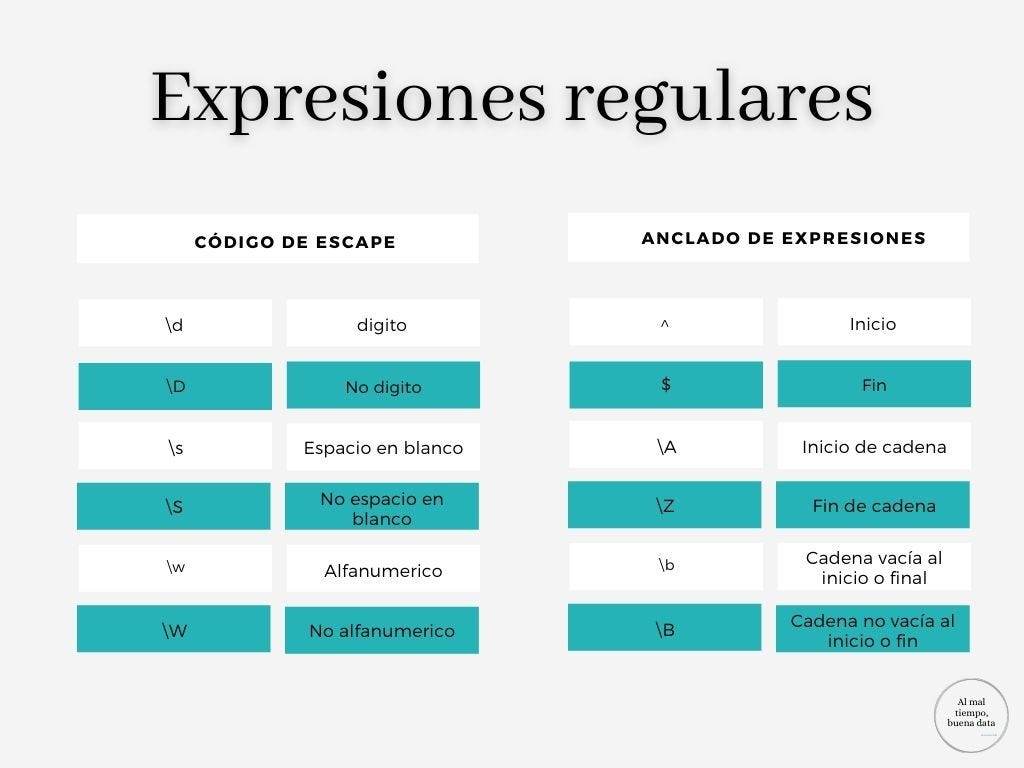

## Importante: Usa Raw Strings

Siempre usa el prefijo `r` para definir patrones regex en Python. Esto evita conflictos con las secuencias de escape de Python.

```python
patron = r'\d+'   # Correcto: raw string
patron = '\\d+'   # Incorrecto: puede causar problemas

Por que? Sin el prefijo r, Python interpreta \d como una secuencia de escape antes de que el motor regex lo vea. El prefijo r le dice a Python: "trata esta cadena literalmente".

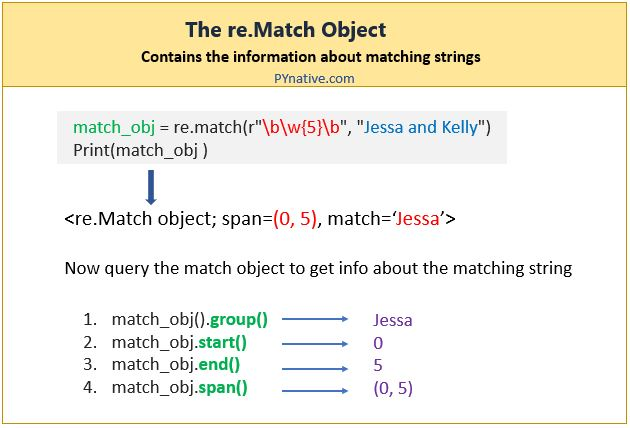

In [2]:
import re

print("=" * 60)
print("METODOS PRINCIPALES DEL MODULO re")
print("=" * 60)

# ============================================================
# 1. re.match() - Busca SOLO al INICIO de la cadena
# ============================================================
print("\n1. re.match() - Solo busca al inicio de la cadena")
print("-" * 60)

resultado = re.match(r'\d+', '123abc')
print(f"re.match(r'\\d+', '123abc'): {resultado.group()}")  # '123'

resultado2 = re.match(r'\d+', 'abc123')
print(f"re.match(r'\\d+', 'abc123'): {resultado2}")  # None (no esta al inicio)



METODOS PRINCIPALES DEL MODULO re

1. re.match() - Solo busca al inicio de la cadena
------------------------------------------------------------
re.match(r'\d+', '123abc'): 123
re.match(r'\d+', 'abc123'): None


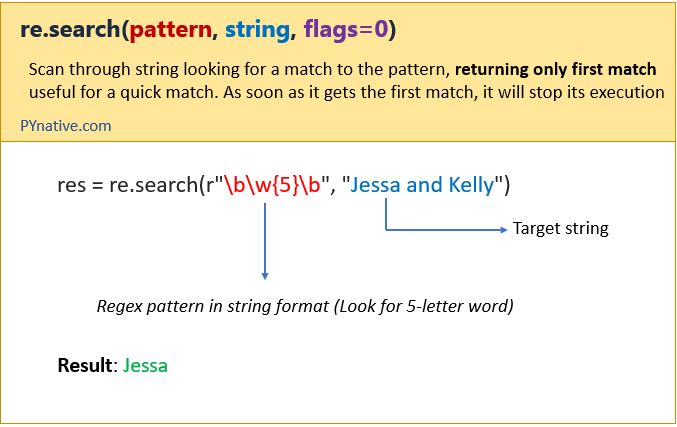

In [3]:
# ============================================================
# 2. re.search() - Busca en CUALQUIER parte de la cadena
# ============================================================
print("\n2. re.search() - Busca en cualquier parte de la cadena")
print("-" * 60)

resultado = re.search(r'\d+', 'abc123def')
print(f"re.search(r'\\d+', 'abc123def'): {resultado.group()}")  # '123'




2. re.search() - Busca en cualquier parte de la cadena
------------------------------------------------------------
re.search(r'\d+', 'abc123def'): 123


In [4]:
# ============================================================
# 3. re.fullmatch() - La cadena COMPLETA debe coincidir
# ============================================================
print("\n3. re.fullmatch() - La cadena COMPLETA debe coincidir")
print("-" * 60)

resultado = re.fullmatch(r'\d+', '12345')
print(f"re.fullmatch(r'\\d+', '12345'): {resultado.group()}")  # '12345'

resultado2 = re.fullmatch(r'\d+', '123abc')
print(f"re.fullmatch(r'\\d+', '123abc'): {resultado2}")  # None




3. re.fullmatch() - La cadena COMPLETA debe coincidir
------------------------------------------------------------
re.fullmatch(r'\d+', '12345'): 12345
re.fullmatch(r'\d+', '123abc'): None


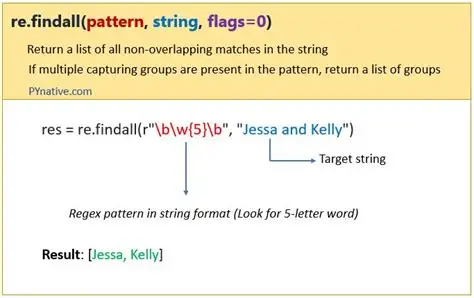

In [5]:
# ============================================================
# 4. re.findall() - Encuentra TODAS las coincidencias
# ============================================================
print("\n4. re.findall() - Encuentra TODAS las coincidencias")
print("-" * 60)

resultado = re.findall(r'\d+', 'abc123def456ghi789')
print(f"re.findall(r'\\d+', 'abc123def456ghi789'): {resultado}")  # ['123', '456', '789']




4. re.findall() - Encuentra TODAS las coincidencias
------------------------------------------------------------
re.findall(r'\d+', 'abc123def456ghi789'): ['123', '456', '789']


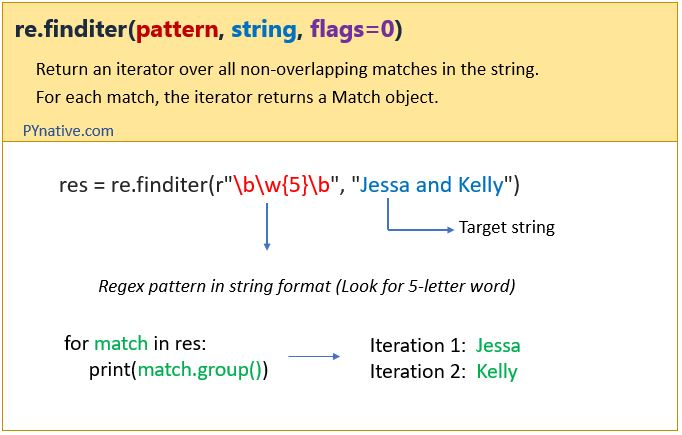

In [6]:
# ============================================================
# 5. re.finditer() - Devuelve iterador con objetos Match
# ============================================================
print("\n5. re.finditer() - Devuelve iterador con posicion")
print("-" * 60)

for match in re.finditer(r'\d+', 'abc123def456'):
    print(f"  Encontrado: {match.group()} en posicion {match.span()}")




5. re.finditer() - Devuelve iterador con posicion
------------------------------------------------------------
  Encontrado: 123 en posicion (3, 6)
  Encontrado: 456 en posicion (9, 12)


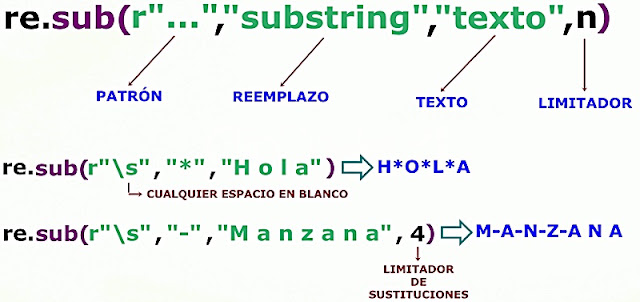

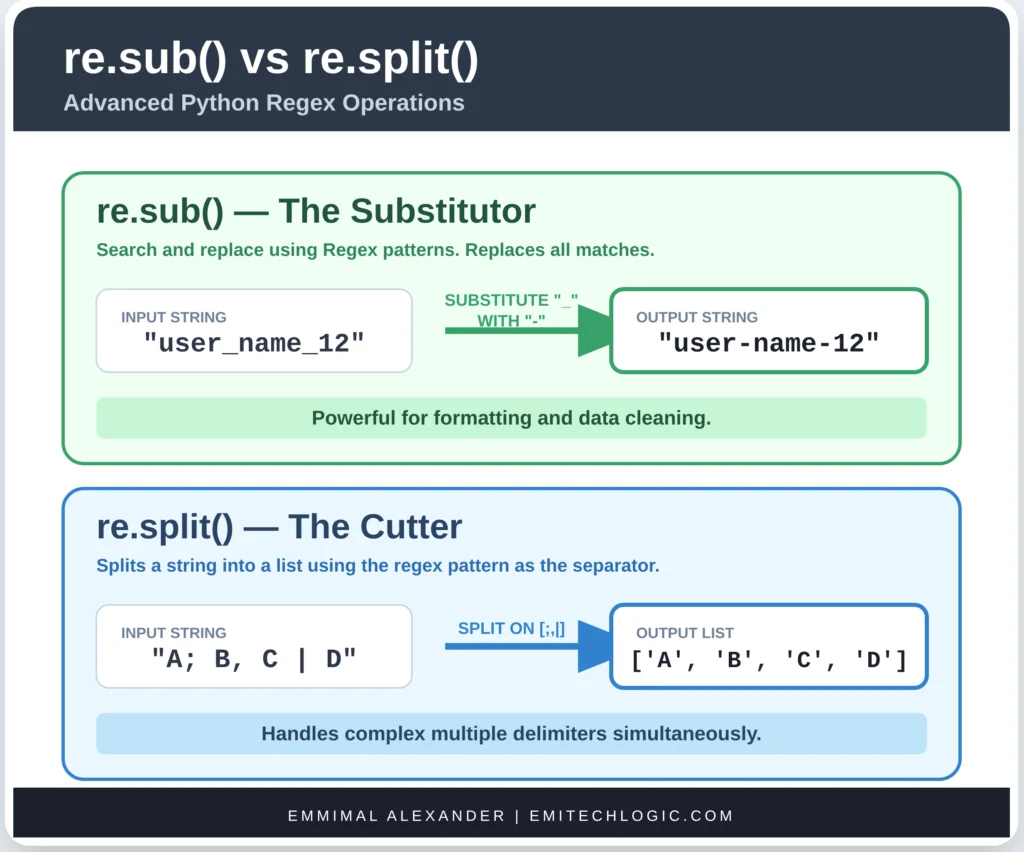

In [7]:
# ============================================================
# 6. re.sub() - Reemplazar coincidencias
# ============================================================
print("\n6. re.sub() - Reemplaza coincidencias")
print("-" * 60)

resultado = re.sub(r'\d+', 'X', 'abc123def456')
print(f"re.sub(r'\\d+', 'X', 'abc123def456'): {resultado}")  # 'abcXdefX'




6. re.sub() - Reemplaza coincidencias
------------------------------------------------------------
re.sub(r'\d+', 'X', 'abc123def456'): abcXdefX


In [8]:
# ============================================================
# 7. re.split() - Dividir cadena
# ============================================================
print("\n7. re.split() - Divide la cadena por el patron")
print("-" * 60)

resultado = re.split(r'[,\s]+', 'uno, dos,  tres   cuatro')
print(f"re.split(r'[,\\s]+', 'uno, dos,  tres   cuatro'): {resultado}")
# ['uno', 'dos', 'tres', 'cuatro']


7. re.split() - Divide la cadena por el patron
------------------------------------------------------------
re.split(r'[,\s]+', 'uno, dos,  tres   cuatro'): ['uno', 'dos', 'tres', 'cuatro']


## Validacion vs Extraccion

Hay dos formas de usar regex, y confundirlas es el error mas comun:

### 1. EXTRACCION
Buscas fragmentos especificos dentro de un texto mas grande.
- Usa: `re.search()`, `re.findall()`, `re.finditer()`
- Ejemplo: "Encuentra todos los numeros de telefono en este parrafo"

### 2. VALIDACION
Quieres verificar si una cadena COMPLETA cumple un formato.
- Usa: `re.fullmatch()` o `re.search()` con `^` y `$`
- Ejemplo: "Verifica si este string es un codigo postal valido"

## Por que importa esto?

Imagina que validas codigos postales mexicanos (5 digitos exactos):

```python
import re

codigo = "12345abc"

# MAL: re.match solo ve el inicio
print(re.match(r'\d{5}', codigo))  # Hace match con "12345" -> FALSO POSITIVO

# BIEN: re.fullmatch exige que TODO el string coincida
print(re.fullmatch(r'\d{5}', codigo))  # None -> Correcto, no es un CP valido

In [9]:
import re

codigo = "12345abc"

# MAL: re.match solo ve el inicio
print(re.match(r'\d{5}', codigo))  # Hace match con "12345" -> FALSO POSITIVO

# BIEN: re.fullmatch exige que TODO el string coincida
print(re.fullmatch(r'\d{5}', codigo))  # None -> Correcto, no es un CP valido

<re.Match object; span=(0, 5), match='12345'>
None


Regla de oro: Cuando valides formatos completos (emails, telefonos, numeros, RFCs), SIEMPRE usa re.fullmatch() o ancla tu patron con ^ al inicio y $ al final.


Esto es especialmente importante para el problema #65 (Valid Number), donde un numero con caracteres extra NO debe considerarse valido.

In [1]:
import re

print("=" * 60)
print("VALIDACION VS EXTRACCION - Ejemplo")
print("=" * 60)

# Caso: Validar codigos postales mexicanos (5 digitos exactos)
codigos = ["12345", "12345abc", "1234", "ABCDE", "06100"]

print("\n--- Usando re.match() (SOLO ve el inicio) ---")
for cp in codigos:
    match = re.match(r'\d{5}', cp)
    es_valido = match is not None
    print(f"  '{cp}' -> {'VALIDO' if es_valido else 'INVALIDO'}")
    # Problema: '12345abc' pasa como valido porque match solo ve el inicio

print("\n--- Usando re.fullmatch() (EXIGE coincidencia completa) ---")
for cp in codigos:
    match = re.fullmatch(r'\d{5}', cp)
    es_valido = match is not None
    print(f"  '{cp}' -> {'VALIDO' if es_valido else 'INVALIDO'}")
    # Correcto: '12345abc' falla porque hay caracteres extra

print("\n--- Alternativa: anclar con ^ y $ usando re.search() ---")
for cp in codigos:
    match = re.search(r'^\d{5}$', cp)
    es_valido = match is not None
    print(f"  '{cp}' -> {'VALIDO' if es_valido else 'INVALIDO'}")

VALIDACION VS EXTRACCION - Ejemplo

--- Usando re.match() (SOLO ve el inicio) ---
  '12345' -> VALIDO
  '12345abc' -> VALIDO
  '1234' -> INVALIDO
  'ABCDE' -> INVALIDO
  '06100' -> VALIDO

--- Usando re.fullmatch() (EXIGE coincidencia completa) ---
  '12345' -> VALIDO
  '12345abc' -> INVALIDO
  '1234' -> INVALIDO
  'ABCDE' -> INVALIDO
  '06100' -> VALIDO

--- Alternativa: anclar con ^ y $ usando re.search() ---
  '12345' -> VALIDO
  '12345abc' -> INVALIDO
  '1234' -> INVALIDO
  'ABCDE' -> INVALIDO
  '06100' -> VALIDO



## Grupos y Capturas

Los parentesis `()` permiten capturar partes especificas del patron.

### Tipos de grupos:

1. **Grupos normales `()`**: Capturan y se pueden acceder con `match.group(n)`
2. **Grupos con nombre `(?P<nombre>...)`**: Se acceden con `match.group('nombre')`

### Cuando usarlos:
- Cuando necesitas extraer partes especificas de un patron
- Cuando quieres aplicar cuantificadores a un grupo completo
- Cuando necesitas referencias hacia atras dentro del mismo patron

In [10]:
import re

print("=" * 60)
print("GRUPOS Y CAPTURAS")
print("=" * 60)

texto = "Producto A: $100, Producto B: $200, Producto C: $300"
patron = r'(\w+): \$(\d+)'

print(f"\nTexto: {texto}")
print(f"Patron: {patron}")

# findall con grupos devuelve tuplas
resultado = re.findall(patron, texto)
print(f"\nre.findall() devuelve: {resultado}")
# [('Producto A', '100'), ('Producto B', '200'), ('Producto C', '300')]

print("\nIterando sobre los resultados:")
for nombre, precio in resultado:
    print(f"  {nombre}: ${precio}")

# Con finditer podemos acceder a los grupos por indice
print("\nUsando re.finditer() con grupos:")
for match in re.finditer(patron, texto):
    print(f"  Grupo 0 (completo): {match.group(0)}")
    print(f"  Grupo 1 (nombre):   {match.group(1)}")
    print(f"  Grupo 2 (precio):   {match.group(2)}")
    print()

GRUPOS Y CAPTURAS

Texto: Producto A: $100, Producto B: $200, Producto C: $300
Patron: (\w+): \$(\d+)

re.findall() devuelve: [('A', '100'), ('B', '200'), ('C', '300')]

Iterando sobre los resultados:
  A: $100
  B: $200
  C: $300

Usando re.finditer() con grupos:
  Grupo 0 (completo): A: $100
  Grupo 1 (nombre):   A
  Grupo 2 (precio):   100

  Grupo 0 (completo): B: $200
  Grupo 1 (nombre):   B
  Grupo 2 (precio):   200

  Grupo 0 (completo): C: $300
  Grupo 1 (nombre):   C
  Grupo 2 (precio):   300



## Analisis de Complejidad en Expresiones Regulares

Cuando resuelvas problemas en LeetCode, deberas justificar la complejidad de tu solucion. Aqui te explico como analizarla para regex.

### Complejidad Temporal

- `re.findall()`, `re.sub()`, `re.split()`, `re.finditer()` recorren la cadena de izquierda a derecha.
- Si la cadena tiene longitud $N$, el tiempo base es $O(N)$.
- Si haces $K$ operaciones regex sobre la misma cadena, el tiempo es $O(K \cdot N)$.

**Cuidado con el backtracking:** Patrones con cuantificadores anidados (como `(a+)+b`) pueden causar backtracking exponencial en el peor caso. Evitalos o usa cuantificadores perezosos (`*?`, `+?`) cuando sea posible.

### Complejidad Espacial

Depende de lo que guardes:
- `re.findall()`: guarda una lista de $K$ coincidencias -> $O(K)$ o $O(N)$ en el peor caso.
- `re.finditer()`: usa un iterador, no guarda todo en memoria -> $O(1)$ adicional.
- Si usas un `set` para contar unicos (como en el problema #929): $O(U)$ donde $U$ son los elementos unicos.
- Si usas un diccionario: $O(U)$ donde $U$ son las claves unicas.

### Como redactar la justificacion

NO pongas solo "O(n) porque si". Incluye:
1. Que haces en cada paso
2. Cuantas veces recorres la cadena
3. Que estructuras auxiliares usas y cuantos elementos guardan



## Problema #929: Unique Email Addresses

### Descripcion:
Cuenta cuantas direcciones de email distintas reciben correo realmente.

### Reglas:
1. Los puntos (`.`) en el nombre local se ignoran
2. Todo lo que sigue a un (`+`) en el nombre local se descarta
3. Estas reglas NO aplican al dominio

### Ejemplo:
"test.email+alex@leetcode.com" -> "testemail@leetcode.com"


"test.e.mail+bob.cathy@leetcode.com" -> "testemail@leetcode.com"


"testemail+david@lee.tcode.com" -> "testemail@lee.tcode.com"

Resultado: 2 emails unicos

### Enfoque sugerido:
1. Usa `re.split()` para separar nombre local y dominio
2. Usa `re.sub()` para eliminar `+` y todo lo que sigue
3. Usa `re.sub()` para eliminar puntos del nombre local
4. Reconstruye el email y guardalo en un `set`




- Documentacion oficial: https://docs.python.org/3/library/re.html

- Regex tester interactivo: https://regex101.com/

- Tutorial visual: https://regexone.com/